# EDA — Stroke Risk AI

## Objetivo

Analizar las características del dataset y estudiar la relación de sus variables con `stroke` antes de realizar el preprocessing y entrenar modelos de Machine Learning.

## Preguntas del análisis

- ¿Cómo está distribuida la variable objetivo `stroke`?
- ¿Existen diferencias de edad entre pacientes con y sin ictus?
- ¿La hipertensión y las enfermedades cardíacas están asociadas con una mayor proporción de ictus?
- ¿Cómo se comportan la glucosa y el BMI en relación con `stroke`?
- ¿Existen diferencias según género, estado civil, tipo de trabajo o residencia?
- ¿Qué relación tiene el hábito tabáquico con `stroke`?
- ¿Qué variables numéricas presentan mayor correlación?

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATA_PATH = Path("../data/raw/stroke_dataset.csv")

df = pd.read_csv(DATA_PATH)

df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


In [1]:
import sys
print(sys.executable)
print(sys.version)

c:\devF5\projects\Proyecto8_DS_MariaHerrero\.venv\Scripts\python.exe
3.12.7 (tags/v3.12.7:0b05ead, Oct  1 2024, 03:06:41) [MSC v.1941 64 bit (AMD64)]


## 1. Estadística descriptiva

Antes de analizar relaciones entre variables, revisamos las principales estadísticas de las variables numéricas del dataset.

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4981.0,43.419859,22.662755,0.08,25.00,45.00,61.00,82.00
hypertension,4981.0,0.096165,0.294848,0.00,0.00,0.00,0.00,1.00
heart_disease,4981.0,0.055210,0.228412,0.00,0.00,0.00,0.00,1.00
avg_glucose_level,4981.0,105.943562,45.075373,55.12,77.23,91.85,113.86,271.74
bmi,4981.0,28.498173,6.790464,14.00,23.70,28.10,32.60,48.90
stroke,4981.0,0.049789,0.217531,0.00,0.00,0.00,0.00,1.00


## 2. Distribución de la variable objetivo `stroke`

**Pregunta:** ¿Está equilibrado el número de pacientes con y sin ictus?

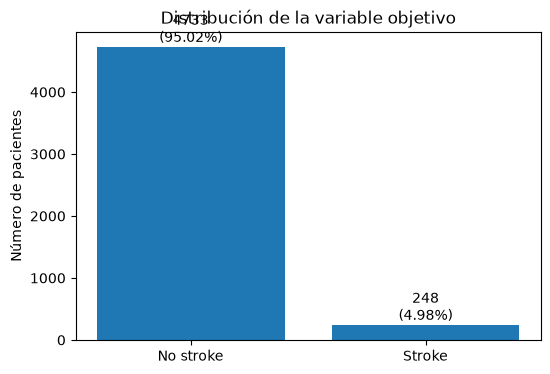

In [4]:
stroke_counts = df["stroke"].value_counts().sort_index()
stroke_percentages = df["stroke"].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(["No stroke", "Stroke"], stroke_counts.values)
ax.set_title("Distribución de la variable objetivo")
ax.set_ylabel("Número de pacientes")

for i, (count, percentage) in enumerate(
    zip(stroke_counts.values, stroke_percentages.values)
):
    ax.text(
        i,
        count,
        f"{count}\n({percentage:.2f}%)",
        ha="center",
        va="bottom",
    )

plt.show()

### Conclusión

La variable objetivo está fuertemente desbalanceada:

- **No stroke (`0`)**: 4.733 casos — 95,02 %.
- **Stroke (`1`)**: 248 casos — 4,98 %.
- **Ratio aproximado**: 19 casos negativos por cada caso positivo.

Este desbalanceo deberá tenerse en cuenta durante el entrenamiento y la evaluación de los modelos. La accuracy no será suficiente como única métrica, ya que un modelo podría obtener una accuracy elevada favoreciendo la clase mayoritaria y, aun así, detectar mal los casos de ictus.

## 3. Edad y `stroke`

**Pregunta:** ¿Existen diferencias de edad entre los pacientes con y sin ictus?

In [5]:
age_by_stroke = df.groupby("stroke")["age"].describe()
age_by_stroke

,count,mean,std,min,25%,50%,75%,max
stroke,,,,,,,,
0,4733.0,42.141348,22.345036,0.08,24.0,43.0,60.0,82.0
1,248.0,67.819839,12.670565,1.32,59.0,71.0,78.0,82.0


Aquí ya aparece una diferencia muy clara:

Sin ictus: edad media 42,14 años, mediana 43.
Con ictus: edad media 67,82 años, mediana 71.

Es una asociación fuerte en este dataset, aunque todavía no podemos decir que la edad cause el ictus.

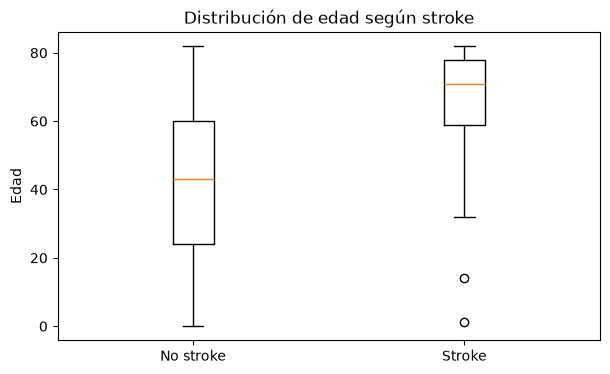

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.boxplot(
    [
        df.loc[df["stroke"] == 0, "age"],
        df.loc[df["stroke"] == 1, "age"],
    ],
    tick_labels=["No stroke", "Stroke"],
)

ax.set_title("Distribución de edad según stroke")
ax.set_ylabel("Edad")

plt.show()

### Conclusión

En este dataset, los pacientes con ictus presentan edades claramente superiores.

- Edad media sin ictus: **42,14 años**.
- Edad media con ictus: **67,82 años**.
- Mediana sin ictus: **43 años**.
- Mediana con ictus: **71 años**.

La edad muestra una asociación importante con `stroke` y probablemente será una variable relevante para los modelos predictivos. Esta relación es estadística y no implica por sí sola causalidad.

## 4. Hipertensión y `stroke`

**Pregunta:** ¿Los pacientes con hipertensión presentan una mayor proporción de ictus?

In [7]:
hypertension_stroke = pd.crosstab(
    df["hypertension"],
    df["stroke"],
    normalize="index",
) * 100

hypertension_stroke

stroke,0,1
hypertension,,
0,95.957352,4.042648
1,86.221294,13.778706


Aquí hay una diferencia bastante clara:

Sin hipertensión: ictus en 4,04 % de los casos.
Con hipertensión: ictus en 13,78 % de los casos.

En este dataset, la proporción de ictus es aproximadamente 3,4 veces mayor entre quienes tienen hipertensión.

Ahora visualizamos esa comparación.

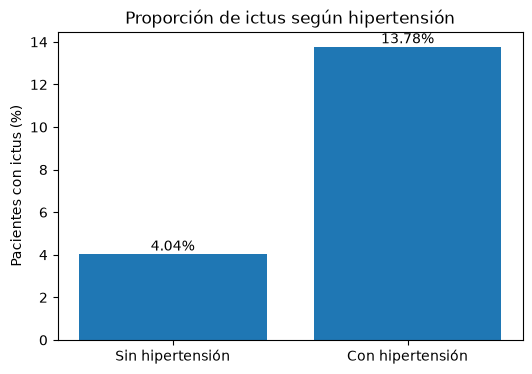

In [8]:
stroke_rate_hypertension = (
    df.groupby("hypertension")["stroke"].mean() * 100
)

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(
    ["Sin hipertensión", "Con hipertensión"],
    stroke_rate_hypertension.values,
)

ax.set_title("Proporción de ictus según hipertensión")
ax.set_ylabel("Pacientes con ictus (%)")

for i, value in enumerate(stroke_rate_hypertension.values):
    ax.text(i, value, f"{value:.2f}%", ha="center", va="bottom")

plt.show()

### Conclusión

La proporción de ictus es considerablemente mayor entre los pacientes con hipertensión:

- Sin hipertensión: **4,04 %** presentan ictus.
- Con hipertensión: **13,78 %** presentan ictus.

En este dataset, los pacientes con hipertensión presentan una proporción de ictus aproximadamente **3,4 veces superior**. Esto muestra una asociación relevante entre `hypertension` y `stroke`, aunque no permite establecer causalidad.

## 5. Enfermedad cardíaca y `stroke`

**Pregunta:** ¿Los pacientes con enfermedad cardíaca presentan una mayor proporción de ictus?

In [9]:
heart_disease_stroke = pd.crosstab(
    df["heart_disease"],
    df["stroke"],
    normalize="index",
) * 100

heart_disease_stroke

stroke,0,1
heart_disease,,
0,95.728857,4.271143
1,82.909091,17.090909


Aquí la diferencia es incluso mayor:

Sin enfermedad cardíaca: ictus en 4,27 %.
Con enfermedad cardíaca: ictus en 17,09 %.
En este dataset, la proporción es aproximadamente 4 veces mayor.

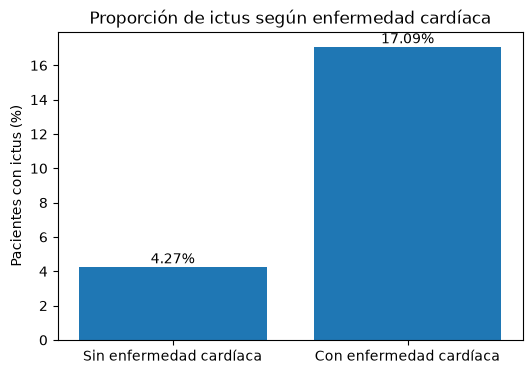

In [10]:
stroke_rate_heart_disease = (
    df.groupby("heart_disease")["stroke"].mean() * 100
)

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(
    ["Sin enfermedad cardíaca", "Con enfermedad cardíaca"],
    stroke_rate_heart_disease.values,
)

ax.set_title("Proporción de ictus según enfermedad cardíaca")
ax.set_ylabel("Pacientes con ictus (%)")

for i, value in enumerate(stroke_rate_heart_disease.values):
    ax.text(i, value, f"{value:.2f}%", ha="center", va="bottom")

plt.show()

### Conclusión

La proporción de ictus es claramente superior entre los pacientes con enfermedad cardíaca:

- Sin enfermedad cardíaca: **4,27 %** presentan ictus.
- Con enfermedad cardíaca: **17,09 %** presentan ictus.

En este dataset, la proporción de ictus entre pacientes con enfermedad cardíaca es aproximadamente **4 veces superior**. `heart_disease` muestra, por tanto, una asociación relevante con `stroke`, aunque esta relación no implica causalidad.

## 6. Nivel medio de glucosa y `stroke`

**Pregunta:** ¿Los pacientes con ictus presentan niveles medios de glucosa diferentes a los pacientes sin ictus?

In [11]:
glucose_by_stroke = df.groupby("stroke")["avg_glucose_level"].describe()
glucose_by_stroke

,count,mean,std,min,25%,50%,75%,max
stroke,,,,,,,,
0,4733.0,104.569056,43.602188,55.12,77.1200,91.45,112.62,267.76
1,248.0,132.175565,61.771083,56.11,79.5725,105.04,195.96,271.74


Hay diferencia:

Sin ictus: glucosa media 104,57, mediana 91,45.
Con ictus: glucosa media 132,18, mediana 105,04.

Además, el grupo con ictus tiene bastante más dispersión, así que el gráfico nos ayudará a verlo.

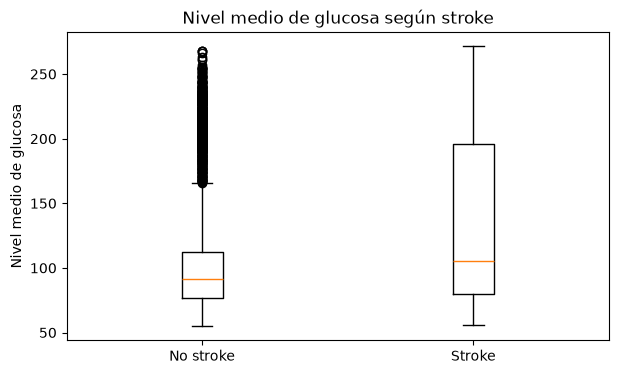

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.boxplot(
    [
        df.loc[df["stroke"] == 0, "avg_glucose_level"],
        df.loc[df["stroke"] == 1, "avg_glucose_level"],
    ],
    tick_labels=["No stroke", "Stroke"],
)

ax.set_title("Nivel medio de glucosa según stroke")
ax.set_ylabel("Nivel medio de glucosa")

plt.show()

### Conclusión

Los pacientes con ictus presentan niveles de glucosa superiores en este dataset:

- Media sin ictus: **104,57**.
- Media con ictus: **132,18**.
- Mediana sin ictus: **91,45**.
- Mediana con ictus: **105,04**.

También se observa una mayor dispersión de los niveles de glucosa entre los pacientes con ictus. `avg_glucose_level` muestra una asociación con `stroke` que deberá evaluarse posteriormente junto con el resto de variables.

## 7. BMI y `stroke`

**Pregunta:** ¿Existen diferencias en el índice de masa corporal (BMI) entre los pacientes con y sin ictus?

In [13]:
bmi_by_stroke = df.groupby("stroke")["bmi"].describe()
bmi_by_stroke

,count,mean,std,min,25%,50%,75%,max
stroke,,,,,,,,
0,4733.0,28.409698,6.833637,14.0,23.500,28.00,32.60,48.9
1,248.0,30.186694,5.658245,16.9,26.975,29.45,32.65,48.9


Aquí la diferencia existe, pero es mucho menor que con edad o glucosa:

Sin ictus → BMI medio 28,41, mediana 28,00.
Con ictus → BMI medio 30,19, mediana 29,45.

Vamos a conservar el análisis estadístico.

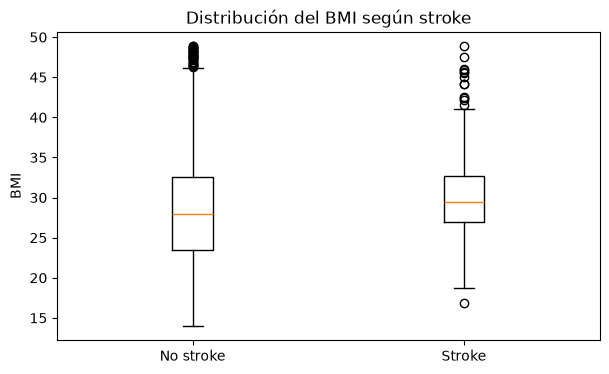

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.boxplot(
    [
        df.loc[df["stroke"] == 0, "bmi"],
        df.loc[df["stroke"] == 1, "bmi"],
    ],
    tick_labels=["No stroke", "Stroke"],
)

ax.set_title("Distribución del BMI según stroke")
ax.set_ylabel("BMI")

plt.show()

### Conclusión

Los pacientes con ictus presentan un BMI ligeramente superior en este dataset:

- BMI medio sin ictus: **28,41**.
- BMI medio con ictus: **30,19**.
- Mediana sin ictus: **28,00**.
- Mediana con ictus: **29,45**.

La diferencia existe, pero es menos marcada que la observada anteriormente en variables como la edad o el nivel medio de glucosa. Por tanto, no debemos asumir únicamente a partir de este análisis que `bmi` tenga una gran capacidad predictiva.

## 8. Género y `stroke`

**Pregunta:** ¿Existen diferencias en la proporción de ictus según el género?

In [15]:
gender_stroke = pd.crosstab(
    df["gender"],
    df["stroke"],
    normalize="index",
) * 100

gender_stroke

stroke,0,1
gender,,
Female,95.184039,4.815961
Male,94.792671,5.207329


Aquí la diferencia es muy pequeña:

Mujeres: 4,82 %
Hombres: 5,21 %

No parece que gender, por sí sola, marque una diferencia importante en este dataset.

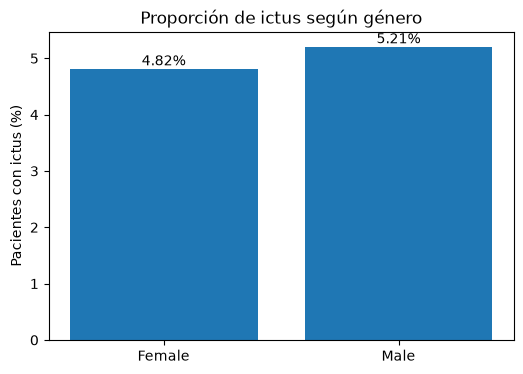

In [16]:
stroke_rate_gender = df.groupby("gender")["stroke"].mean() * 100

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(
    stroke_rate_gender.index,
    stroke_rate_gender.values,
)

ax.set_title("Proporción de ictus según género")
ax.set_ylabel("Pacientes con ictus (%)")

for i, value in enumerate(stroke_rate_gender.values):
    ax.text(i, value, f"{value:.2f}%", ha="center", va="bottom")

plt.show()

### Conclusión

La proporción de ictus es muy similar entre ambos géneros:

- Mujeres: **4,82 %**.
- Hombres: **5,21 %**.

Aunque los hombres presentan una proporción ligeramente superior, la diferencia observada es pequeña. Por tanto, en este análisis descriptivo `gender` no muestra una asociación tan marcada con `stroke` como variables como la edad, la hipertensión o la enfermedad cardíaca.

## 9. Estado civil y `stroke`

**Pregunta:** ¿Existen diferencias en la proporción de ictus entre las personas que han estado casadas y las que no?

Aquí hay que tener cuidado: aunque aparezca una diferencia grande, no podremos concluir que estar casado esté relacionado directamente con sufrir un ictus.

ever_married probablemente está muy relacionada con age: las personas mayores tienen mucha más probabilidad de haber estado casadas y ya hemos visto que la edad presenta una asociación muy fuerte con stroke.

In [17]:
married_stroke = pd.crosstab(
    df["ever_married"],
    df["stroke"],
    normalize="index",
) * 100

married_stroke

stroke,0,1
ever_married,,
No,98.295121,1.704879
Yes,93.323171,6.676829


Aquí sí aparece una diferencia considerable:

Nunca casados: 1,70 % con ictus.
Han estado casados: 6,68 % con ictus.

Pero no debemos interpretar que el matrimonio aumenta el riesgo de ictus. La edad puede explicar buena parte de esta diferencia.

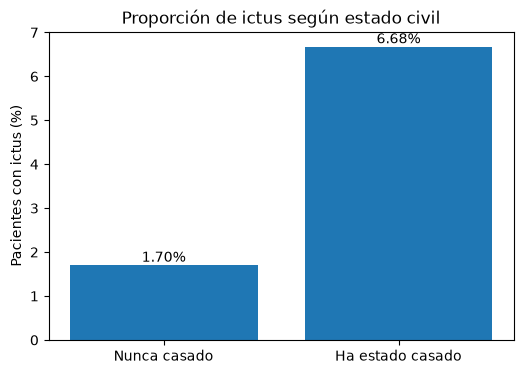

In [18]:
stroke_rate_married = df.groupby("ever_married")["stroke"].mean() * 100

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(
    ["Nunca casado", "Ha estado casado"],
    stroke_rate_married.reindex(["No", "Yes"]).values,
)

ax.set_title("Proporción de ictus según estado civil")
ax.set_ylabel("Pacientes con ictus (%)")

for i, value in enumerate(stroke_rate_married.reindex(["No", "Yes"]).values):
    ax.text(i, value, f"{value:.2f}%", ha="center", va="bottom")

plt.show()

### Conclusión

La proporción de ictus es superior entre las personas que han estado casadas:

- Nunca casados: **1,70 %**.
- Han estado casados: **6,68 %**.

Sin embargo, esta diferencia debe interpretarse con cautela. `ever_married` puede estar relacionada con la edad: las personas de mayor edad tienen más probabilidad de haber estado casadas y, como hemos observado anteriormente, la edad presenta una fuerte asociación con `stroke`.

Por tanto, estos resultados muestran una asociación en el dataset, pero no permiten atribuir el mayor porcentaje de ictus al estado civil.

## 10. Tipo de trabajo y `stroke`

**Pregunta:** ¿Existen diferencias en la proporción de ictus según el tipo de trabajo?

De nuevo tendremos cuidado con la edad: por ejemplo, la categoría children tendrá necesariamente pacientes mucho más jóvenes, así que comparar directamente los porcentajes puede resultar engañoso.

In [19]:
work_stroke = pd.crosstab(
    df["work_type"],
    df["stroke"],
    normalize="index",
) * 100

work_stroke

stroke,0,1
work_type,,
Govt_job,94.875776,5.124224
Private,94.825175,5.174825
Self-employed,91.915423,8.084577
children,99.702823,0.297177


Aquí vemos diferencias importantes:

Self-employed: 8,08 %
Private: 5,17 %
Govt_job: 5,12 %
children: 0,30 %

Pero nuevamente la edad probablemente está influyendo mucho. Especialmente evidente en children.

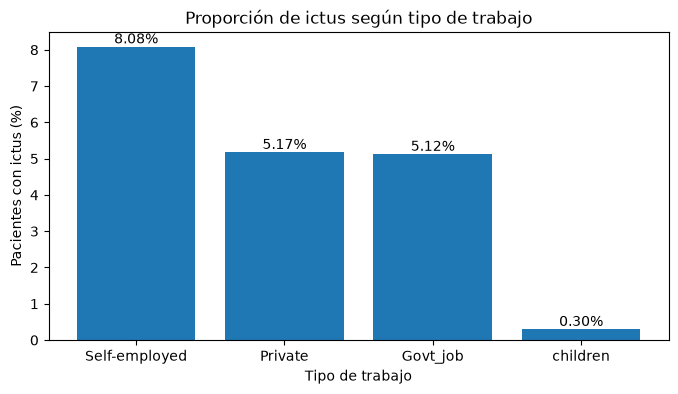

In [20]:
stroke_rate_work = df.groupby("work_type")["stroke"].mean() * 100
stroke_rate_work = stroke_rate_work.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(stroke_rate_work.index, stroke_rate_work.values)

ax.set_title("Proporción de ictus según tipo de trabajo")
ax.set_ylabel("Pacientes con ictus (%)")
ax.set_xlabel("Tipo de trabajo")

for i, value in enumerate(stroke_rate_work.values):
    ax.text(i, value, f"{value:.2f}%", ha="center", va="bottom")

plt.show()

### Conclusión

La proporción de ictus varía según el tipo de trabajo:

- `Self-employed`: **8,08 %**.
- `Private`: **5,17 %**.
- `Govt_job`: **5,12 %**.
- `children`: **0,30 %**.

El grupo `Self-employed` presenta la mayor proporción de ictus, mientras que `children` presenta una proporción muy baja.

Estas diferencias deben interpretarse con cautela, ya que `work_type` puede estar relacionado con la edad. La baja proporción observada en `children`, por ejemplo, es coherente con la fuerte asociación entre mayor edad y `stroke` detectada anteriormente.

## 11. Tipo de residencia y `stroke`

**Pregunta:** ¿Existen diferencias en la proporción de ictus entre pacientes de zonas urbanas y rurales?

Aquí queremos comprobar si vivir en una zona Urban o Rural presenta alguna asociación visible con stroke.

In [21]:
residence_stroke = pd.crosstab(
    df["Residence_type"],
    df["stroke"],
    normalize="index",
) * 100

residence_stroke

stroke,0,1
Residence_type,,
Rural,95.385872,4.614128
Urban,94.668246,5.331754


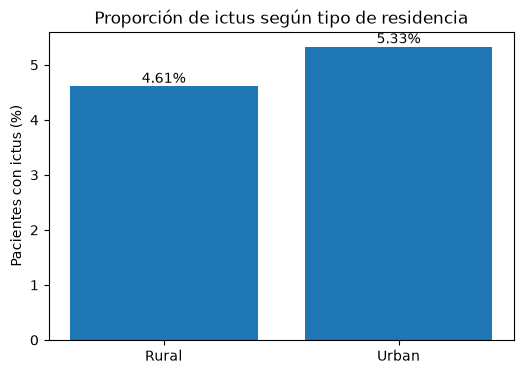

In [22]:
stroke_rate_residence = df.groupby("Residence_type")["stroke"].mean() * 100

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(
    stroke_rate_residence.index,
    stroke_rate_residence.values,
)

ax.set_title("Proporción de ictus según tipo de residencia")
ax.set_ylabel("Pacientes con ictus (%)")

for i, value in enumerate(stroke_rate_residence.values):
    ax.text(i, value, f"{value:.2f}%", ha="center", va="bottom")

plt.show()

### Conclusión

La proporción de ictus es similar entre ambos tipos de residencia:

- Rural: **4,61 %**.
- Urbana: **5,33 %**.

Aunque la proporción es ligeramente superior en zonas urbanas, la diferencia observada es pequeña. En este análisis descriptivo, `Residence_type` no muestra una asociación tan marcada con `stroke` como la edad, la hipertensión o la enfermedad cardíaca.

## 12. Hábito tabáquico y `stroke`

**Pregunta:** ¿Existen diferencias en la proporción de ictus según el hábito tabáquico?

Aquí tenemos cuatro categorías:

never smoked
formerly smoked
smokes
Unknown

Unknown es importante: no significa que la persona no fume, sino que desconocemos su hábito tabáquico. Por eso la mantendremos separada y no sacaremos conclusiones sobre tabaquismo a partir de ese grupo.

In [23]:
smoking_stroke = pd.crosstab(
    df["smoking_status"],
    df["stroke"],
    normalize="index",
) * 100

smoking_stroke

stroke,0,1
smoking_status,,
Unknown,96.866667,3.133333
formerly smoked,91.926182,8.073818
never smoked,95.157780,4.842220
smokes,94.587629,5.412371


Aquí aparece una diferencia interesante:

formerly smoked: 8,07 %
smokes: 5,41 %
never smoked: 4,84 %
Unknown: 3,13 %

Pero ojo: no debemos concluir que haber dejado de fumar sea peor que fumar actualmente. El grupo formerly smoked podría contener personas de mayor edad, y ya sabemos que la edad está muy asociada con stroke.

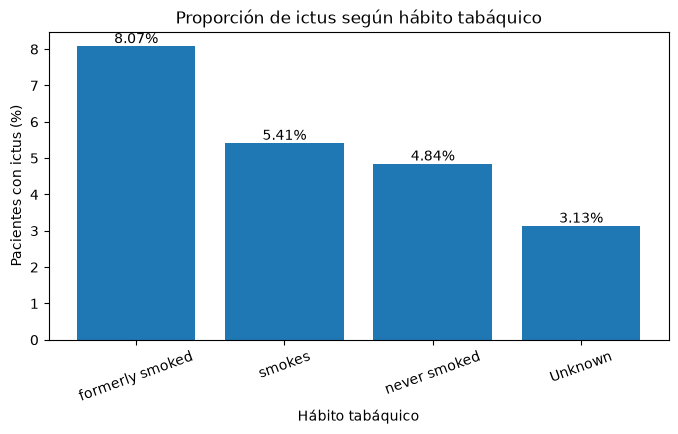

In [24]:
stroke_rate_smoking = df.groupby("smoking_status")["stroke"].mean() * 100
stroke_rate_smoking = stroke_rate_smoking.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(
    stroke_rate_smoking.index,
    stroke_rate_smoking.values,
)

ax.set_title("Proporción de ictus según hábito tabáquico")
ax.set_ylabel("Pacientes con ictus (%)")
ax.set_xlabel("Hábito tabáquico")

for i, value in enumerate(stroke_rate_smoking.values):
    ax.text(i, value, f"{value:.2f}%", ha="center", va="bottom")

plt.xticks(rotation=20)
plt.show()

### Conclusión

La proporción de ictus varía según el hábito tabáquico:

- `formerly smoked`: **8,07 %**.
- `smokes`: **5,41 %**.
- `never smoked`: **4,84 %**.
- `Unknown`: **3,13 %**.

El grupo `formerly smoked` presenta la mayor proporción de ictus. Sin embargo, estos resultados deben interpretarse con cautela, ya que otras variables, especialmente la edad, pueden influir en esta asociación.

Además, `Unknown` representa información no disponible sobre el hábito tabáquico y no debe interpretarse como una categoría clínica equivalente a las demás.

## 13. Análisis de correlaciones

**Pregunta:** ¿Qué relaciones lineales existen entre las variables numéricas y binarias, y cuáles presentan mayor correlación con `stroke`?

La correlación permite medir cómo varían dos variables conjuntamente. Sus valores se encuentran entre -1 y 1:

- Cercano a **1**: relación positiva fuerte.
- Cercano a **-1**: relación negativa fuerte.
- Cercano a **0**: poca relación lineal.

La correlación no implica causalidad.

In [25]:
correlation_columns = [
    "age",
    "hypertension",
    "heart_disease",
    "avg_glucose_level",
    "bmi",
    "stroke",
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix.round(3)

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
age,1.000,0.278,0.265,0.237,0.374,0.246
hypertension,0.278,1.000,0.112,0.170,0.159,0.132
heart_disease,0.265,0.112,1.000,0.167,0.061,0.135
avg_glucose_level,0.237,0.170,0.167,1.000,0.186,0.133
bmi,0.374,0.159,0.061,0.186,1.000,0.057
stroke,0.246,0.132,0.135,0.133,0.057,1.000


Aquí tenemos algo interesante: la variable con mayor correlación lineal con stroke es age (0,246). Después aparecen bastante próximas heart_disease, avg_glucose_level e hypertension. bmi tiene una correlación lineal bastante baja con stroke (0,057).

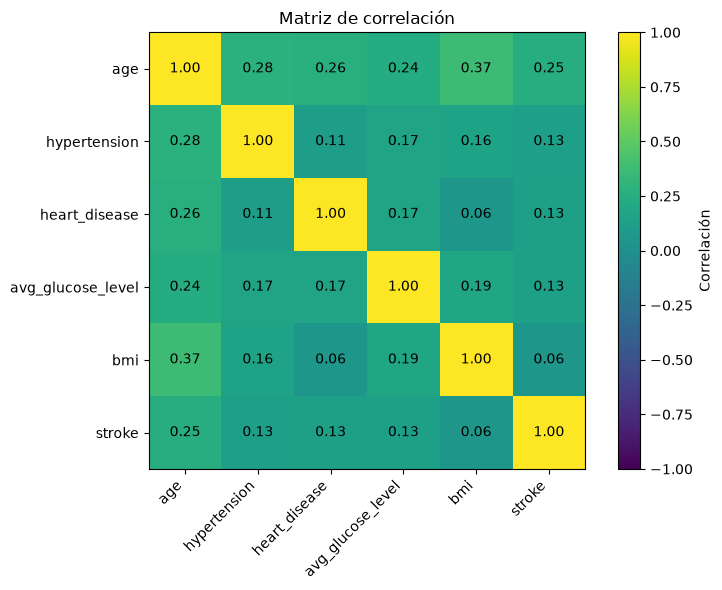

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))

image = ax.imshow(correlation_matrix, vmin=-1, vmax=1)

ax.set_xticks(range(len(correlation_columns)))
ax.set_yticks(range(len(correlation_columns)))

ax.set_xticklabels(correlation_columns, rotation=45, ha="right")
ax.set_yticklabels(correlation_columns)

for i in range(len(correlation_columns)):
    for j in range(len(correlation_columns)):
        ax.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
        )

fig.colorbar(image, ax=ax, label="Correlación")
ax.set_title("Matriz de correlación")

plt.tight_layout()
plt.show()

### Conclusión

Dentro de las variables analizadas, `age` presenta la mayor correlación lineal positiva con `stroke` (**0,246**).

Las correlaciones con `stroke` son:

- `age`: **0,246**
- `heart_disease`: **0,135**
- `avg_glucose_level`: **0,133**
- `hypertension`: **0,132**
- `bmi`: **0,057**

No se observan correlaciones lineales fuertes con `stroke`. Esto no significa que las variables carezcan de capacidad predictiva: pueden existir relaciones no lineales, interacciones entre variables y efectos que un coeficiente de correlación simple no refleja.

También destaca la correlación entre `age` y `bmi` (**0,374**), la mayor observada entre dos variables predictoras de esta matriz.

## 14. Distribuciones de las variables numéricas

**Pregunta:** ¿Cómo se distribuyen la edad, el nivel medio de glucosa y el BMI en el conjunto completo de pacientes?

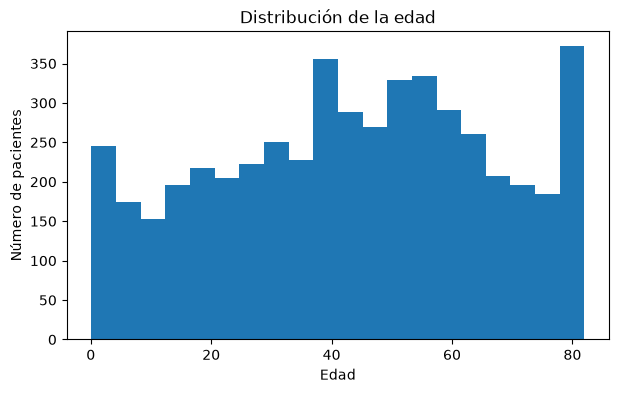

In [27]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(df["age"], bins=20)

ax.set_title("Distribución de la edad")
ax.set_xlabel("Edad")
ax.set_ylabel("Número de pacientes")

plt.show()

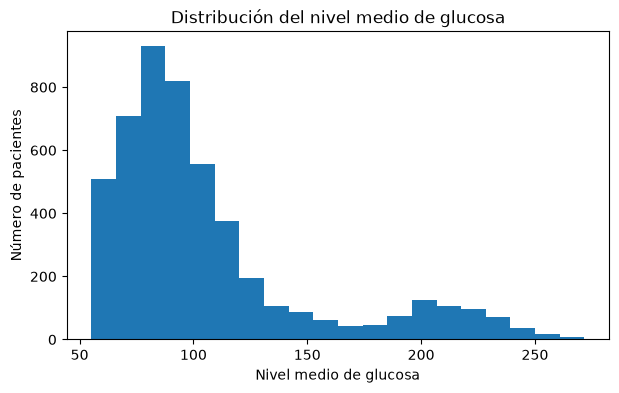

In [28]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(df["avg_glucose_level"], bins=20)

ax.set_title("Distribución del nivel medio de glucosa")
ax.set_xlabel("Nivel medio de glucosa")
ax.set_ylabel("Número de pacientes")

plt.show()

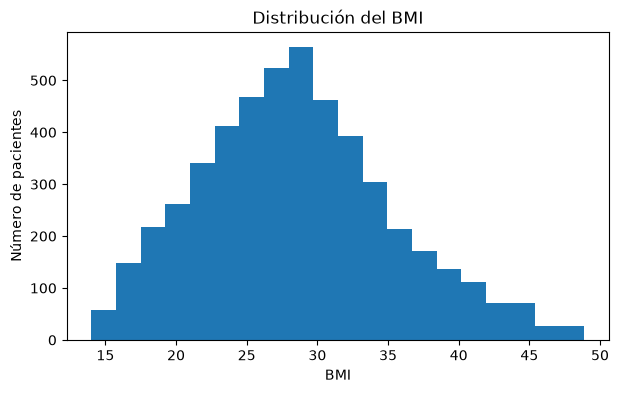

In [29]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(df["bmi"], bins=20)

ax.set_title("Distribución del BMI")
ax.set_xlabel("BMI")
ax.set_ylabel("Número de pacientes")

plt.show()

### Conclusiones sobre las distribuciones numéricas

**Edad**

La edad presenta una distribución amplia, con pacientes desde edades muy tempranas hasta los 82 años. No se observa una concentración alrededor de un único rango de edad, por lo que el dataset contiene representación de distintas etapas de la vida.

**Nivel medio de glucosa**

La distribución de `avg_glucose_level` es claramente asimétrica. La mayoría de los pacientes se concentra aproximadamente entre 70 y 120, pero existe otro grupo de observaciones con valores considerablemente más altos, especialmente alrededor de 180-230.

Esta distribución ayuda a explicar la diferencia entre la media y la mediana observada anteriormente y sugiere que esta variable podría contener patrones relevantes para la predicción de `stroke`.

**BMI**

El BMI presenta una distribución aproximadamente unimodal, concentrándose principalmente alrededor de valores entre 25 y 32. A partir de esos valores, la frecuencia disminuye progresivamente hacia los BMI más elevados.

En conjunto, las tres variables presentan distribuciones diferentes, algo que deberá tenerse en cuenta posteriormente durante el preprocessing y el entrenamiento de los modelos.

## 15. Conclusiones generales del EDA

El análisis exploratorio permite identificar varios patrones relevantes antes de comenzar el preprocessing y el entrenamiento de modelos.

### Principales hallazgos

- **`stroke` está fuertemente desbalanceada**: solo el **4,98 %** de los registros corresponde a pacientes con ictus, frente al **95,02 %** sin ictus. Este será uno de los principales retos del modelado.

- **La edad destaca como una de las variables más relevantes**. Los pacientes con ictus tienen una edad media de **67,82 años**, frente a **42,14 años** en los pacientes sin ictus. Además, `age` presenta la mayor correlación lineal con `stroke` (**0,246**) entre las variables analizadas.

- **La hipertensión muestra una asociación importante**. El **13,78 %** de los pacientes con hipertensión presenta ictus, frente al **4,04 %** de los pacientes sin hipertensión.

- **La enfermedad cardíaca presenta una asociación especialmente marcada**. El porcentaje de ictus alcanza el **17,09 %** entre los pacientes con enfermedad cardíaca, frente al **4,27 %** entre quienes no la presentan.

- **El nivel medio de glucosa también muestra diferencias**. Los pacientes con ictus presentan una media de **132,18**, frente a **104,57** en los pacientes sin ictus. Su distribución es además claramente asimétrica.

- **El BMI presenta diferencias más moderadas**. La media es de **30,19** entre pacientes con ictus y **28,41** entre pacientes sin ictus.

- **`gender` y `Residence_type` muestran diferencias pequeñas** en la proporción de ictus, por lo que su asociación individual con la variable objetivo parece limitada en este análisis descriptivo.

- Variables como **`ever_married`, `work_type` y `smoking_status` muestran diferencias entre categorías**, pero deben interpretarse con cautela porque pueden estar relacionadas con otras variables, especialmente con la edad.

### Consideraciones para el modelado

El EDA muestra que no existe una única variable capaz de explicar por sí sola la aparición de `stroke`. Será necesario estudiar conjuntamente las distintas características mediante modelos de Machine Learning.

El fuerte desbalanceo de la variable objetivo deberá tenerse especialmente en cuenta. La **accuracy no será suficiente como única métrica de evaluación**, por lo que será necesario prestar atención a métricas adecuadas para la detección de la clase minoritaria.

Las asociaciones observadas durante este análisis son relaciones estadísticas dentro del dataset y **no implican causalidad médica**.